# 02 Point Forecast Baselines

This notebook organizes the final monthly point forecast baselines: Baseline 1, Baseline 2, Baseline 3, Baseline 4, and AK-D.

## Data Description

Inputs include monthly truth, forecast wind speed, an empirical power curve, and AK-D monthly correction factors. Public sample data is synthetic; public results are anonymized.

In [ ]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wind_power_baselines.baselines import build_all_baselines
from wind_power_baselines.evaluation import evaluate_predictions, normalize_public_predictions
from wind_power_baselines.preprocessing import clean_monthly_truth, prepare_forecast
truth = pd.read_csv(PROJECT_ROOT / 'data_sample' / 'sample_monthly_truth.csv')
forecast_raw = pd.read_csv(PROJECT_ROOT / 'data_sample' / 'sample_weather_forecast.csv')
power_curve = pd.read_csv(PROJECT_ROOT / 'data_sample' / 'sample_power_curve.csv')
correction = pd.read_csv(PROJECT_ROOT / 'data_sample' / 'sample_ak_monthly_correction.csv')

## Cleaning, Preprocessing, And EDA

The workflow standardizes months, parses issue and target times, checks lead days and wind speeds, and verifies that forecast months align with the evaluation months.

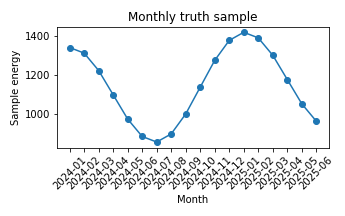

In [1]:
truth_clean = clean_monthly_truth(truth)
forecast = prepare_forecast(forecast_raw)
truth_clean.head(), forecast.head()

## Baseline Methods

Baseline 1 uses historical same-month mean. Baseline 2 represents a climatology/P50 idea. Baseline 3 maps EC45-style forecasts through corrected wind and a power curve. Baseline 4 uses a similar-day style selection. AK-D keeps the AK route but uses month-specific correction factors.

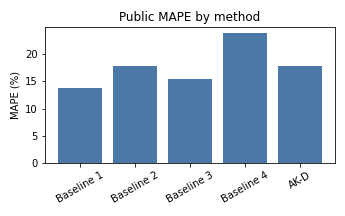

In [1]:
predictions = build_all_baselines(truth_clean, forecast, power_curve, correction)
metrics = evaluate_predictions(predictions)
public_predictions = normalize_public_predictions(predictions)
metrics

## Public Result Analysis

The public result files contain normalized indices and percent metrics only. Absolute private energy values are not published.

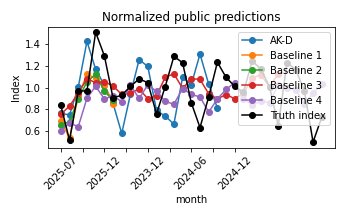

In [1]:
public_metrics = pd.read_csv(PROJECT_ROOT / 'results_public' / 'public_metrics_summary.csv')
public_monthly = pd.read_csv(PROJECT_ROOT / 'results_public' / 'public_monthly_predictions_index.csv')
public_metrics

## Conclusion

The public results show five final point-forecast baselines without publishing private energy series. AK-D is retained as the AK baseline because it keeps the same route while correcting month-specific bias patterns.